In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import re
import random
import time
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
Tesla T4
Memory: 15.6 GB


In [3]:
data_path = "/content/drive/MyDrive/AI ML-LastSem/Week9/npi.txt"
lines = pd.read_table(data_path, names=['source', 'target', 'comments'])
if 'comments' in lines.columns:
    lines = lines.drop(columns=['comments'])

def clean_text_data(df):
    df = df.copy()
    df.source = df.source.apply(lambda x: x.lower())
    df.target = df.target.apply(lambda x: x.lower())
    df.source = df.source.apply(lambda x: re.sub(r'[\"\u2018\u2019\u201c\u201d]', '', x))
    df.target = df.target.apply(lambda x: re.sub(r'[\"\u2018\u2019\u201c\u201d]', '', x))
    df.source = df.source.apply(lambda x: re.sub(r'\d+', '', x))
    df.target = df.target.apply(lambda x: re.sub(r'\d+', '', x))
    df.source = df.source.apply(lambda x: re.sub(r'\s+', ' ', x.strip()))
    df.target = df.target.apply(lambda x: re.sub(r'\s+', ' ', x.strip()))
    df.target = df.target.apply(lambda x: f'START_ {x} _END')
    df.rename(columns={'source': 'cleaned_source', 'target': 'cleaned_target'}, inplace=True)
    return df

cleaned_data = clean_text_data(lines)
print(cleaned_data.shape)
cleaned_data.sample(3)

(2689, 2)


,cleaned_source,cleaned_target
685,you have three pens.,START_ तिमीसँग तीनवटा कलम छन्। _END
1015,i visited tom in boston.,START_ म बोस्टनमा टमलाई भेट्न गएँ। _END
2435,tom was kind of chubby in the third grade.,START_ टम तेस्रो कक्षामा एक प्रकारको मोटो थियो...


In [4]:
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

all_source_words = set()
for s in cleaned_data.cleaned_source:
    for w in s.split():
        all_source_words.add(w)

all_target_words = set()
for t in cleaned_data.cleaned_target:
    for w in t.split():
        all_target_words.add(w)

source_words = sorted(list(all_source_words))
target_words = sorted(list(all_target_words))

source_word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
source_word2idx.update({w: i+2 for i, w in enumerate(source_words)})
target_word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
target_word2idx.update({w: i+2 for i, w in enumerate(target_words)})

source_idx2word = {i: w for w, i in source_word2idx.items()}
target_idx2word = {i: w for w, i in target_word2idx.items()}

max_source_len = max(len(s.split()) for s in cleaned_data.cleaned_source)
max_target_len = max(len(t.split()) for t in cleaned_data.cleaned_target)

num_encoder_tokens = len(source_word2idx)
num_decoder_tokens = len(target_word2idx)

print(f'Source vocab: {num_encoder_tokens}, Target vocab: {num_decoder_tokens}')
print(f'Max source len: {max_source_len}, Max target len: {max_target_len}')

Source vocab: 2689, Target vocab: 3271
Max source len: 25, Max target len: 22


In [5]:
cleaned_data = shuffle(cleaned_data)
X = cleaned_data.cleaned_source.values
y = cleaned_data.cleaned_target.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

Train: 2420, Test: 269


In [6]:
class TranslationDataset(Dataset):
    def __init__(self, sources, targets, src_w2i, tgt_w2i, max_src_len, max_tgt_len):
        src_ids_list, dec_in_list, dec_tgt_list = [], [], []
        for s, t in zip(sources, targets):
            si = [src_w2i.get(w, 1) for w in s.split()]
            ti = [tgt_w2i.get(w, 1) for w in t.split()]
            si = (si + [0]*max_src_len)[:max_src_len]
            ti = (ti + [0]*max_tgt_len)[:max_tgt_len]
            src_ids_list.append(si)
            dec_in_list.append(ti[:-1])
            dec_tgt_list.append(ti[1:])
        self.src_ids = torch.tensor(src_ids_list, dtype=torch.long)
        self.dec_in  = torch.tensor(dec_in_list,  dtype=torch.long)
        self.dec_tgt = torch.tensor(dec_tgt_list, dtype=torch.long)

    def __len__(self):
        return len(self.src_ids)

    def __getitem__(self, idx):
        return self.src_ids[idx], self.dec_in[idx], self.dec_tgt[idx]

batch_size  = 256
num_workers = 2

print('Building datasets (pre-tokenising)...')
train_dataset = TranslationDataset(X_train, y_train, source_word2idx, target_word2idx, max_source_len, max_target_len)
test_dataset = TranslationDataset(X_test,  y_test,  source_word2idx, target_word2idx, max_source_len, max_target_len)

pin = (device.type == 'cuda')
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          drop_last=True, num_workers=num_workers, pin_memory=pin, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          drop_last=True, num_workers=num_workers, pin_memory=pin, persistent_workers=True)
print(f'Train batches: {len(train_loader)}, Test batches: {len(test_loader)}')

Building datasets (pre-tokenising)...
Train batches: 9, Test batches: 1


In [7]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=n_layers,
                          batch_first=True, bidirectional=True, dropout=dropout)
        self.fc = nn.Linear(hidden_dim * 2, hidden_dim)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        outputs, hidden = self.rnn(emb)
        hidden = torch.tanh(self.fc(
            torch.cat((hidden[-2], hidden[-1]), dim=1)
        ))
        return outputs, hidden


class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 3, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        B, T, _ = encoder_outputs.shape
        h = hidden.unsqueeze(1).repeat(1, T, 1)
        energy = torch.tanh(self.attn(torch.cat((h, encoder_outputs), dim=2)))
        attn_weights = torch.softmax(self.v(energy).squeeze(2), dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        return context, attn_weights


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.attention = Attention(hidden_dim)
        self.rnn = nn.GRU(embed_dim + hidden_dim * 2, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim * 3 + embed_dim, vocab_size)

    def forward(self, x, hidden, encoder_outputs):
        emb = self.dropout(self.embedding(x))
        context, _ = self.attention(hidden, encoder_outputs)
        rnn_input = torch.cat((emb, context), dim=2)
        out, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        hidden = hidden.squeeze(0)
        pred = self.fc(torch.cat((out, context, emb), dim=2))
        return pred, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        encoder_outputs, hidden = self.encoder(src)
        B, T = tgt.shape
        V = self.decoder.fc.out_features
        outputs = torch.zeros(B, T, V, device=src.device)
        dec_input = tgt[:, 0:1]
        for t in range(T):
            logits, hidden = self.decoder(dec_input, hidden, encoder_outputs)
            outputs[:, t:t+1, :] = logits
            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt[:, t:t+1] if use_teacher else logits.argmax(-1)
        return outputs


EMBED_DIM = 256
HIDDEN_DIM = 512

encoder = Encoder(num_encoder_tokens, EMBED_DIM, HIDDEN_DIM).to(device)
decoder = Decoder(num_decoder_tokens, EMBED_DIM, HIDDEN_DIM).to(device)
model = Seq2Seq(encoder, decoder).to(device)

try:
    model = torch.compile(model)
    print('torch.compile enabled')
except Exception:
    print('torch.compile not available, running eager mode')

print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

torch.compile enabled
Total parameters: 18,548,679


In [8]:
CHECKPOINT_PATH = "/content/drive/MyDrive/AI ML-LastSem/Week9/nmt_checkpoint.pt"
MAX_TRAIN_HOURS = 2.5
MAX_EPOCHS = 100
CLIP_GRAD = 1.0

if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print('Removed old checkpoint, starting fresh.')

criterion = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=0.1)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-6)

train_losses, val_losses = [], []
wall_start = time.time()

for epoch in range(MAX_EPOCHS):
    elapsed_h = (time.time() - wall_start) / 3600
    if elapsed_h >= MAX_TRAIN_HOURS:
        print(f'Time budget reached at epoch {epoch}.')
        break

    tf_ratio = max(0.3, 0.9 - epoch * 0.006)

    model.train()
    total_loss = 0
    t0 = time.time()
    for enc_in, dec_in, dec_tgt in train_loader:
        enc_in = enc_in.to(device, non_blocking=True)
        dec_in = dec_in.to(device, non_blocking=True)
        dec_tgt = dec_tgt.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(enc_in, dec_in, teacher_forcing_ratio=tf_ratio)
        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), dec_tgt.reshape(B * T))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        total_loss += loss.item()

    avg_train = total_loss / len(train_loader)
    train_losses.append(avg_train)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for enc_in, dec_in, dec_tgt in test_loader:
            enc_in = enc_in.to(device, non_blocking=True)
            dec_in = dec_in.to(device, non_blocking=True)
            dec_tgt = dec_tgt.to(device, non_blocking=True)
            logits = model(enc_in, dec_in, teacher_forcing_ratio=0.0)
            B, T, V = logits.shape
            loss = criterion(logits.reshape(B * T, V), dec_tgt.reshape(B * T))
            val_loss += loss.item()

    avg_val = val_loss / len(test_loader)
    val_losses.append(avg_val)

    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(avg_val)
    new_lr = optimizer.param_groups[0]['lr']
    lr_msg = f' | LR -> {new_lr:.2e}' if new_lr != prev_lr else ''

    epoch_secs = time.time() - t0
    total_elapsed = (time.time() - wall_start) / 3600
    print(f'Epoch {epoch+1:3d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | '
          f'TF: {tf_ratio:.2f} | {epoch_secs:.0f}s | Elapsed: {total_elapsed:.2f}h{lr_msg}')

    torch.save({
        'epoch': epoch, 'model': model.state_dict(),
        'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(),
        'train_losses': train_losses, 'val_losses': val_losses,
    }, CHECKPOINT_PATH)

print('Training complete.')

Removed old checkpoint, starting fresh.


W0515 05:55:22.849000 18658 torch/_inductor/utils.py:1679] [3/0_1] Not enough SMs to use max_autotune_gemm mode


Epoch   1 | Train: 7.1091 | Val: 6.3928 | TF: 0.90 | 16s | Elapsed: 0.00h
Epoch   2 | Train: 6.0392 | Val: 6.1926 | TF: 0.89 | 4s | Elapsed: 0.01h
Epoch   3 | Train: 5.6290 | Val: 5.9991 | TF: 0.89 | 4s | Elapsed: 0.01h
Epoch   4 | Train: 5.2117 | Val: 5.8346 | TF: 0.88 | 4s | Elapsed: 0.01h
Epoch   5 | Train: 4.7937 | Val: 5.7116 | TF: 0.88 | 4s | Elapsed: 0.01h
Epoch   6 | Train: 4.4283 | Val: 5.6195 | TF: 0.87 | 4s | Elapsed: 0.01h
Epoch   7 | Train: 3.9973 | Val: 5.5764 | TF: 0.86 | 4s | Elapsed: 0.01h
Epoch   8 | Train: 3.7018 | Val: 5.4948 | TF: 0.86 | 4s | Elapsed: 0.01h
Epoch   9 | Train: 3.4056 | Val: 5.4902 | TF: 0.85 | 4s | Elapsed: 0.02h
Epoch  10 | Train: 3.1566 | Val: 5.4338 | TF: 0.85 | 4s | Elapsed: 0.02h
Epoch  11 | Train: 2.9063 | Val: 5.4041 | TF: 0.84 | 4s | Elapsed: 0.02h
Epoch  12 | Train: 2.7877 | Val: 5.3842 | TF: 0.83 | 4s | Elapsed: 0.02h
Epoch  13 | Train: 2.7049 | Val: 5.3188 | TF: 0.83 | 4s | Elapsed: 0.02h
Epoch  14 | Train: 2.4383 | Val: 5.2770 | TF: 0.82

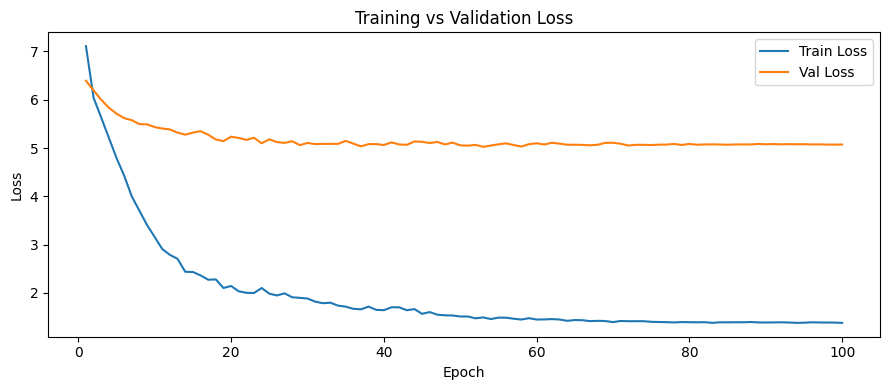

In [9]:
epochs_done = len(train_losses)
plt.figure(figsize=(9, 4))
plt.plot(range(1, epochs_done+1), train_losses, label='Train Loss')
plt.plot(range(1, epochs_done+1), val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
def decode_sequence(sentence, max_len=50):
    model.eval()
    words = sentence.lower().split()
    ids = [source_word2idx.get(w, 1) for w in words]
    ids = (ids + [0] * max_source_len)[:max_source_len]
    src = torch.tensor([ids], dtype=torch.long).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = encoder(src)
        tgt = torch.tensor([[target_word2idx['START_']]], dtype=torch.long).to(device)
        result = []
        for _ in range(max_len):
            logits, hidden = decoder(tgt, hidden, encoder_outputs)
            pred = logits.argmax(-1)
            word = target_idx2word.get(pred.item(), UNK_TOKEN)
            if word == '_END':
                break
            result.append(word)
            tgt = pred
    return ' '.join(result)

for _ in range(5):
    idx = random.randint(0, len(X_test) - 1)
    src_sent = X_test[idx]
    tgt_sent = y_test[idx].replace('START_ ', '').replace(' _END', '')
    pred = decode_sequence(src_sent)
    print(f'Source: {src_sent}')
    print(f'Target: {tgt_sent}')
    print(f'Predicted: {pred}')
    print()

Source: how old are you?
Target: तपाई कति बर्सको हुनु भयो ?
Predicted: तिम्रो उमेर कति भयो ?

Source: i thought tom would be pleased.
Target: मैले सोचें कि टम खुसी हुनेछ।
Predicted: मैले सोचे कि टम यो हुनेछ।

Source: tom is sleeping in the living room.
Target: टम बैठक कोठामा सुतिरहेको छ।
Predicted: टम पर्खालमा बसिरहेको छ।

Source: i didn't know tom had a cold.
Target: टमलाई चिसो लागेको मलाई थाहा थिएन।
Predicted: मलाई थाहा छ मलाई थाहा थिएन।

Source: i don't want to be killed.
Target: म मारिन चाहन्न।
Predicted: म एक्लै बस्न चाहन्न।

